# 11 · Consolidación del grupo **EXAMINATION**

**Proyecto:** Modelo de longevidad NHANES 2017-2018 (ciclo `_J`)
**Capa:** `01_raw` (.xpt) → **`02_intermediate`** → `03_primary`

## Objetivo
Unir los **2 datasets de examen físico** en un dataset intermedio, conservando solo las
columnas relevantes y construyendo las features antropométricas y de presión arterial.

**Datasets de este grupo (2):**
- `bmx_j` — medidas corporales (peso, talla, IMC, circunferencias).
- `bpxo_j` — presión arterial **oscilométrica** (3 lecturas de sistólica/diastólica/pulso).

## Decisiones clave
- **Presión arterial:** se usa la **media de las lecturas 2 y 3** y se descarta la 1ª
  (efecto "bata blanca"); de ahí salen sistólica, diastólica, **presión de pulso**
  (rigidez arterial) y pulso en reposo.
- **Antropometría:** preferimos índices de adiposidad central (cintura/talla, cintura/cadera)
  sobre el IMC crudo, mejores predictores de riesgo en envejecimiento.
- Las columnas `BMI...` (con I) son **flags de calidad** del examen, no el IMC; se descartan.


## 1. Setup

In [1]:
%load_ext kedro.ipython

[06/16/26 13:32:31] INFO     Using                                                                  ]8;id=14963975;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\framework\project\__init__.py\__init__.py]8;;\:]8;id=14963976;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\framework\project\__init__.py#281\281]8;;\
                             'C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages                
                             \kedro\framework\project\rich_logging.yml' as logging configuration.                  

                    INFO     Registered line magic '%reload_kedro'                                   ]8;id=14963983;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=14963984;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\ipython\__init__.py#67\67]8;;\

                    INFO     Registered line magic '%load_node'                                      ]8;id=14963990;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=14963991;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\ipython\__init__.py#69\69]8;;\

                    INFO     Resolved project path as:                                              ]8;id=14963997;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=14963998;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\ipython\__init__.py#193\193]8;;\
                             C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes.                                        
                             To set a different path, run '%reload_kedro <project_root>'                           

[06/16/26 13:32:32] INFO     No typed parameter requirements found, returning original   ]8;id=14964005;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\validation\parameter_validator.py\parameter_validator.py]8;;\:]8;id=14964006;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\validation\parameter_validator.py#124\124]8;;\
                             parameters                                                                            

[06/16/26 13:32:33] INFO     Kedro is sending anonymous usage data with the sole purpose of improving ]8;id=14964013;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro_telemetry\plugin.py\plugin.py]8;;\:]8;id=14964014;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro_telemetry\plugin.py#273\273]8;;\
                             the product. No personal data or IP addresses are stored on our side. To              
                             opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK` environment              
                             variables, or create a `.telemetry` file in the current working                       
                             directory with the contents `consent: false`. To hide this message,                   
                             explicitly grant or deny consent. Read more at                                        
                             https://docs.kedro.org/en/stable/about/telemetry/                                     

[06/16/26 13:32:34] INFO     Kedro project Nhanes                                                   ]8;id=14964020;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=14964021;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\ipython\__init__.py#159\159]8;;\

                    INFO     Defined global variable 'context', 'session', 'catalog' and            ]8;id=14964027;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=14964028;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\ipython\__init__.py#160\160]8;;\
                             'pipelines'                                                                           

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 120)
plt.rcParams["figure.dpi"] = 110

PROJ = Path(context.project_path)
OUT_DIR = PROJ / "data" / "02_intermediate"
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("Salida:", OUT_DIR)

Salida: C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\data\02_intermediate


## 2. Carga de los datasets de examen

In [3]:
raw = {
    "bmx":  catalog.load("bmx_j_dataset"),
    "bpxo": catalog.load("bpxo_j_dataset"),
}
for k, v in raw.items():
    print(f"{k:6s} filas={v.shape[0]:6d} columnas={v.shape[1]:3d}")

                    INFO     Loading data from bmx_j_dataset (GenericDataset)...               ]8;id=14964035;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=14964036;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\io\data_catalog.py#1053\1053]8;;\

                    INFO     Loading data from bpxo_j_dataset (GenericDataset)...              ]8;id=14964041;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=14964042;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\io\data_catalog.py#1053\1053]8;;\

bmx    filas=  8704 columnas= 21
bpxo   filas=  7132 columnas= 13


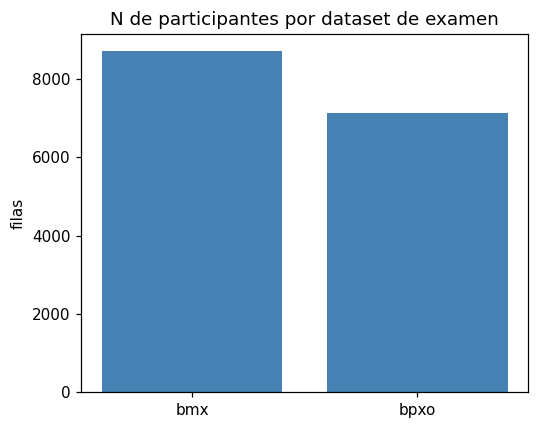

In [4]:
# Grafico 1: N por dataset
ns = {k: v.shape[0] for k, v in raw.items()}
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(ns.keys(), ns.values(), color="steelblue")
ax.set_title("N de participantes por dataset de examen")
ax.set_ylabel("filas"); plt.tight_layout(); plt.show()

## 3. Selección de columnas relevantes (Filtro 1)

### BMX — convención
- `BMX...` = la **medición** (peso, talla, IMC, circunferencias). **Conservar** las útiles.
- `BMI...` = **flag de comentario/calidad** de cada medida (p. ej. "no se pudo medir"). **Eliminar**.
- `BMXRECUM`, `BMXHEAD` = longitud recostado y perímetro cefálico (lactantes). **Eliminar** (cohorte adulta).

### BPXO — convención
- `BPXOSY1/2/3`, `BPXODI1/2/3`, `BPXOPLS1/2/3` = 3 lecturas de sist./diast./pulso.
- `BPAOARM`, `BPAOCSZ`, `BPAOMNTS` = brazo, tamaño de brazalete, minutos de descanso → técnico, **eliminar**.

In [5]:
# Columnas crudas que conservamos de cada dataset
BMX_KEEP = {
    "BMXBMI":   "Índice de masa corporal (kg/m2)",
    "BMXWAIST": "Circunferencia de cintura (cm) - adiposidad central",
    "BMXHIP":   "Circunferencia de cadera (cm) - para cintura/cadera",
    "BMXHT":    "Talla de pie (cm) - para cintura/talla",
    "BMXARMC":  "Circunferencia de brazo (cm) - proxy de masa muscular",
}
BPXO_KEEP = ["BPXOSY2", "BPXOSY3", "BPXODI2", "BPXODI3", "BPXOPLS2", "BPXOPLS3"]

bmx = raw["bmx"][["SEQN"] + list(BMX_KEEP)].copy()
bpxo = raw["bpxo"][["SEQN"] + BPXO_KEEP].copy()
for d in (bmx, bpxo):
    d["SEQN"] = d["SEQN"].astype("int64")
print("BMX:", bmx.shape, "| BPXO:", bpxo.shape)

BMX: (8704, 6) | BPXO: (7132, 7)


## 4. Merge interno por `SEQN` (outer join)

In [6]:
exam = (bmx.drop_duplicates("SEQN").set_index("SEQN")
           .join(bpxo.drop_duplicates("SEQN").set_index("SEQN"), how="outer"))
print("Tabla de examen combinada:", exam.shape)
exam.head()

Tabla de examen combinada: (8704, 11)


,BMXBMI,BMXWAIST,BMXHIP,BMXHT,BMXARMC,BPXOSY2,BPXOSY3,BPXODI2,BPXODI3,BPXOPLS2,BPXOPLS3
SEQN,,,,,,,,,,,
93703,17.5,48.2,NaN,88.6,16.2,NaN,NaN,NaN,NaN,NaN,NaN
93704,15.7,50.0,NaN,94.2,15.2,NaN,NaN,NaN,NaN,NaN,NaN
93705,31.7,101.8,110.0,158.3,32.0,165.0,172.0,66.0,66.0,51.0,49.0
93706,21.5,79.3,94.4,175.7,27.0,128.0,133.0,68.0,71.0,83.0,73.0
93707,18.1,64.1,83.0,158.4,21.5,133.0,139.0,72.0,71.0,89.0,91.0


## 5. Limpieza de rangos fisiológicos

No hay códigos 7/9 en mediciones físicas; el missing ya viene como `NaN`. Solo descartamos
valores **imposibles** (errores de medición).

In [7]:
PLAUSIBLE = {
    "BMXBMI":   (12, 70),     # IMC
    "BMXWAIST": (40, 200),    # cintura cm
    "BMXHIP":   (50, 200),    # cadera cm
    "BMXHT":    (120, 220),   # talla cm (adultos)
    "BMXARMC":  (15, 60),     # brazo cm
    "BPXOSY2":  (70, 260), "BPXOSY3": (70, 260),
    "BPXODI2":  (30, 160), "BPXODI3": (30, 160),
    "BPXOPLS2": (30, 200), "BPXOPLS3": (30, 200),
}
before = exam.isna().sum().sum()
for col, (lo, hi) in PLAUSIBLE.items():
    if col in exam.columns:
        exam.loc[(exam[col] < lo) | (exam[col] > hi), col] = np.nan
print("Valores imposibles -> NaN:", exam.isna().sum().sum() - before)

Valores imposibles -> NaN: 1075


## 6. Ingeniería de características

| Feature | Fórmula | Reemplaza | Señal |
|---|---|---|---|
| `sistolica` | media(SY2, SY3) | 3 lecturas sistólicas | descarta lectura 1 (bata blanca) |
| `diastolica` | media(DI2, DI3) | 3 lecturas diastólicas | — |
| `pulso` | media(PLS2, PLS3) | 3 lecturas de pulso | frecuencia cardiaca en reposo |
| `presion_pulso` | sistólica − diastólica | — | **rigidez arterial** (predictor de envejecimiento vascular) |
| `cintura_talla` (WHtR) | cintura / talla | cadera/talla crudas | adiposidad central ajustada por estatura |
| `cintura_cadera` (WHR) | cintura / cadera | cadera cruda | distribución de grasa androide |

In [8]:
# Presion arterial: media de lecturas 2 y 3
exam["sistolica"]  = exam[["BPXOSY2", "BPXOSY3"]].mean(axis=1)
exam["diastolica"] = exam[["BPXODI2", "BPXODI3"]].mean(axis=1)
exam["pulso"]      = exam[["BPXOPLS2", "BPXOPLS3"]].mean(axis=1)
exam["presion_pulso"] = exam["sistolica"] - exam["diastolica"]

# Indices antropometricos
exam["cintura_talla"]  = exam["BMXWAIST"] / exam["BMXHT"]
exam["cintura_cadera"] = exam["BMXWAIST"] / exam["BMXHIP"]

# Descartamos lecturas crudas y la cadera (ya contenida en los ratios)
DROP = ["BPXOSY2", "BPXOSY3", "BPXODI2", "BPXODI3", "BPXOPLS2", "BPXOPLS3", "BMXHIP"]
exam = exam.drop(columns=[c for c in DROP if c in exam.columns])

# Renombrado legible
exam = exam.rename(columns={
    "BMXBMI": "imc", "BMXWAIST": "cintura", "BMXHT": "altura", "BMXARMC": "circ_brazo",
})
print("Tras feature engineering:", exam.shape)
print("Columnas:", list(exam.columns))

Tras feature engineering: (8704, 10)
Columnas: ['imc', 'cintura', 'altura', 'circ_brazo', 'sistolica', 'diastolica', 'pulso', 'presion_pulso', 'cintura_talla', 'cintura_cadera']


## 7. Visualizaciones de control

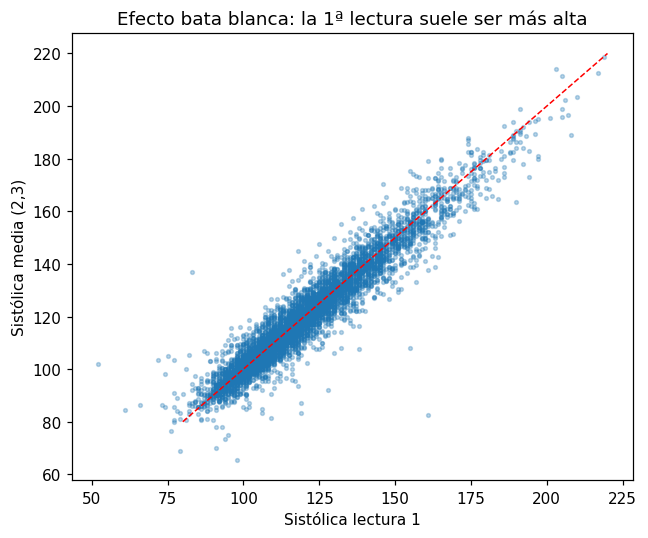

Media lectura1: 120.5 | Media (2,3): 120.2


In [9]:
# Grafico 2: efecto bata blanca -> lectura 1 vs media(2,3) de sistolica
bp = raw["bpxo"].copy()
m23 = bp[["BPXOSY2", "BPXOSY3"]].mean(axis=1)
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(bp["BPXOSY1"], m23, s=6, alpha=0.3)
lims = [80, 220]
ax.plot(lims, lims, "r--", lw=1)
ax.set_xlabel("Sistólica lectura 1"); ax.set_ylabel("Sistólica media (2,3)")
ax.set_title("Efecto bata blanca: la 1ª lectura suele ser más alta")
plt.tight_layout(); plt.show()
print("Media lectura1:", round(bp['BPXOSY1'].mean(),1),
      "| Media (2,3):", round(m23.mean(),1))

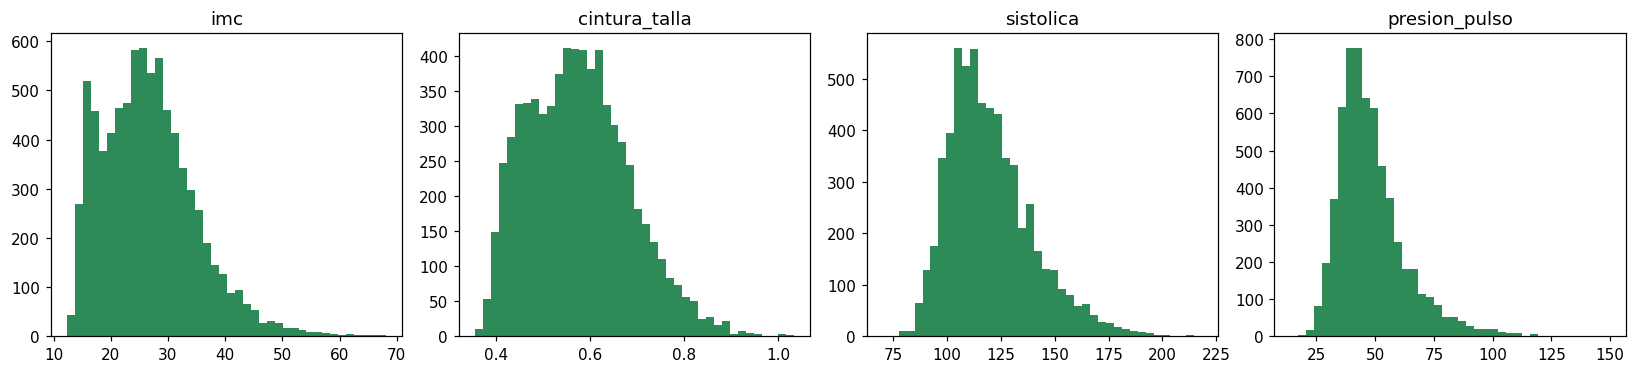

In [10]:
# Grafico 3: distribuciones de las features clave
feats = ["imc", "cintura_talla", "sistolica", "presion_pulso"]
fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))
for ax, c in zip(axes, feats):
    ax.hist(exam[c].dropna(), bins=40, color="seagreen")
    ax.set_title(c)
plt.tight_layout(); plt.show()

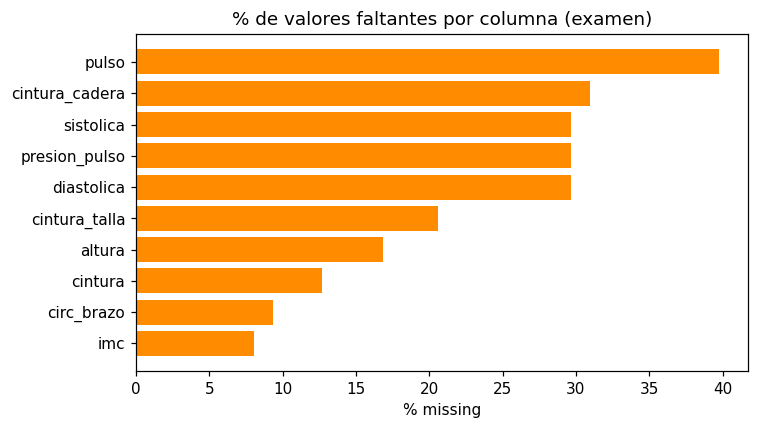

,%_missing
pulso,39.7
cintura_cadera,30.9
sistolica,29.7
presion_pulso,29.7
diastolica,29.6
cintura_talla,20.6
altura,16.9
cintura,12.7
circ_brazo,9.3
imc,8.1


In [11]:
# Grafico 4: % missing por columna
miss = (exam.isna().mean() * 100).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(miss.index[::-1], miss.values[::-1], color="darkorange")
ax.set_title("% de valores faltantes por columna (examen)")
ax.set_xlabel("% missing"); plt.tight_layout(); plt.show()
miss.round(1).to_frame("%_missing")

## 8. Exportación a `02_intermediate`

In [12]:
out_path = OUT_DIR / "exam_intermediate.parquet"
exam.to_parquet(out_path)
print("Guardado:", out_path, "| shape:", exam.shape)
exam.head()

Guardado: C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\data\02_intermediate\exam_intermediate.parquet | shape: (8704, 10)


,imc,cintura,altura,circ_brazo,sistolica,diastolica,pulso,presion_pulso,cintura_talla,cintura_cadera
SEQN,,,,,,,,,,
93703,17.5,48.2,NaN,16.2,NaN,NaN,NaN,NaN,NaN,NaN
93704,15.7,50.0,NaN,15.2,NaN,NaN,NaN,NaN,NaN,NaN
93705,31.7,101.8,158.3,32.0,168.5,66.0,50.0,102.5,0.643083,0.925455
93706,21.5,79.3,175.7,27.0,130.5,69.5,78.0,61.0,0.451338,0.840042
93707,18.1,64.1,158.4,21.5,136.0,71.5,90.0,64.5,0.404672,0.772289


## 9. Conclusiones del grupo Examination

- De **2 datasets** (34 columnas crudas, muchas de ellas flags) llegamos a una tabla compacta de
  features de examen físico.
- Presión arterial resumida con la **media de lecturas 2-3** (evita el sesgo de la 1ª) y derivamos
  `presion_pulso` como marcador de rigidez arterial.
- Antropometría centrada en **adiposidad central** (`cintura_talla`, `cintura_cadera`) más que en IMC solo.
- Sin imputación/escalado (se hace post-split para evitar fuga de información).

### Referencias
- Ashwell, M., et al. (2012). *Waist-to-height ratio as an indicator of early health risk.* Obes Rev.
- CDC/NCHS. *NHANES 2017-2018 Examination Data — Body Measures & Oscillometric Blood Pressure.*
